In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
FILE = "product_dataset_100k.csv"   # ← update path if needed
sns.set_theme(style="whitegrid", palette="muted")

In [11]:
#loading data
df = pd.read_csv(FILE)
 
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print()
print("First 5 rows:")
print(df.head())
print()
print("Last 5 rows:")
print(df.tail())

Shape: 100,000 rows × 8 columns
Columns: ['product_id', 'product_name', 'price', 'date_of_purchase', 'user_review', 'rating', 'review_length', 'sentiment']

First 5 rows:
   product_id     product_name    price date_of_purchase  \
0           1  Smartphone Case      NaN       21-04-2023   
1           2     Laptop Stand   690.72       15-10-2022   
2           3       Power Bank  4857.81       08-11-2022   
3           4     Laptop Stand      NaN       27-05-2023   
4           5     Laptop Stand  3428.57       12-05-2024   

                                         user_review  rating  review_length  \
0  I have been using this for a few weeks now and...       5             25   
1  Poor build quality and not very reliable in lo...       4             18   
2  Poor build quality and not very reliable in lo...       1             18   
3  The quality is average and could be improved i...       5             21   
4  It works fine but sometimes shows inconsistenc...       2             

In [12]:
#missing value 
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
print(missing_df)
print()
 
# Key finding: price has ~10% nulls
print("▶ price column: 9,970 nulls (~9.97% of rows)")
print("  Strategy options:")
print("  (a) Drop rows  → df.dropna(subset=['price'])")
print("  (b) Fill median → df['price'].fillna(df['price'].median(), inplace=True)")
print("  (c) Fill per product median:")
df["price_filled"] = df.groupby("product_name")["price"] \
                       .transform(lambda x: x.fillna(x.median()))
print("      'price_filled' column created (per-product median imputation).")

                  missing_count  missing_%
product_id                    0       0.00
product_name                  0       0.00
price                      9970       9.97
date_of_purchase              0       0.00
user_review                   0       0.00
rating                        0       0.00
review_length                 0       0.00
sentiment                     0       0.00

▶ price column: 9,970 nulls (~9.97% of rows)
  Strategy options:
  (a) Drop rows  → df.dropna(subset=['price'])
  (b) Fill median → df['price'].fillna(df['price'].median(), inplace=True)
  (c) Fill per product median:
      'price_filled' column created (per-product median imputation).


In [13]:
#checking duplicate data 
total_dups = df.duplicated().sum()
id_dups    = df["product_id"].duplicated().sum()
 
print(f"Fully duplicate rows : {total_dups}")
print(f"Duplicate product_id : {id_dups}")
print("✓ No duplicates found.")

Fully duplicate rows : 0
Duplicate product_id : 0
✓ No duplicates found.


In [14]:
#checking outlier(iqr)
print(df[["price_filled", "rating", "review_length"]].describe().round(2))
print()
 
# IQR outlier check on price
Q1, Q3 = df["price_filled"].quantile([0.25, 0.75])
IQR = Q3 - Q1
low_fence  = Q1 - 1.5 * IQR
high_fence = Q3 + 1.5 * IQR
outliers = df[(df["price_filled"] < low_fence) | (df["price_filled"] > high_fence)]
print(f"Price IQR fences   : [{low_fence:.2f}, {high_fence:.2f}]")
print(f"Outliers (IQR)     : {len(outliers)} → price is uniformly distributed, no outliers.")
 

       price_filled     rating  review_length
count     100000.00  100000.00      100000.00
mean        2599.83       3.01          20.19
std         1316.62       1.41           2.04
min          200.11       1.00          18.00
25%         1525.71       2.00          19.00
50%         2595.27       3.00          19.00
75%         3672.04       4.00          21.00
max         4999.89       5.00          25.00

Price IQR fences   : [-1693.78, 6891.52]
Outliers (IQR)     : 0 → price is uniformly distributed, no outliers.


In [25]:
#distribution of data catagorically
print("\nproduct_name counts:")
print(df["product_name"].value_counts())
 
print("\nsentiment counts:")
print(df["sentiment"].value_counts())
 
print("\nrating counts:")
print(df["rating"].value_counts().sort_index())
 
print("\nRating × Sentiment crosstab:")
print(pd.crosstab(df["rating"], df["sentiment"]))
print("▶ Perfect mapping: 1-2 → negative, 3 → neutral, 4-5 → positive")
 



product_name counts:
product_name
Laptop Stand                   10166
USB-C Charger                  10110
Noise Cancelling Headphones    10097
Smart Watch                    10078
LED Monitor                    10034
Bluetooth Speaker               9996
Smartphone Case                 9939
Gaming Keyboard                 9903
Power Bank                      9860
Wireless Mouse                  9817
Name: count, dtype: int64

sentiment counts:
sentiment
positive    40163
negative    39776
neutral     20061
Name: count, dtype: int64

rating counts:
rating
1    19933
2    19843
3    20061
4    20076
5    20087
Name: count, dtype: int64

Rating × Sentiment crosstab:
sentiment  negative  neutral  positive
rating                                
1             19933        0         0
2             19843        0         0
3                 0    20061         0
4                 0        0     20076
5                 0        0     20087
▶ Perfect mapping: 1-2 → negative, 3 → neutral, 4-5 →

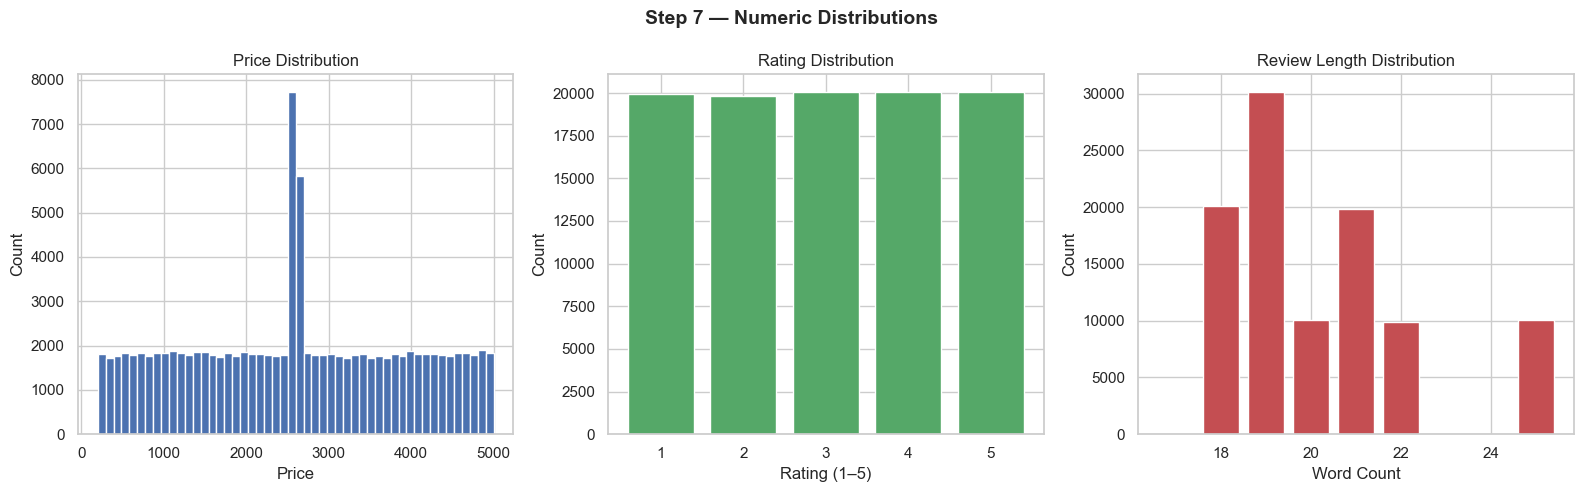

Saved: step7_distributions.png


In [26]:
# numeric based ploting 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Step 7 — Numeric Distributions", fontsize=14, fontweight="bold")
 
# Price histogram
axes[0].hist(df["price_filled"].dropna(), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")
 
# Rating bar chart
rating_counts = df["rating"].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values, color="#55A868", edgecolor="white")
axes[1].set_title("Rating Distribution")
axes[1].set_xlabel("Rating (1–5)")
axes[1].set_ylabel("Count")
 
# Review length histogram
axes[2].hist(df["review_length"], bins=range(17, 27), color="#C44E52", edgecolor="white",
             align="left", rwidth=0.8)
axes[2].set_title("Review Length Distribution")
axes[2].set_xlabel("Word Count")
axes[2].set_ylabel("Count")
 
plt.tight_layout()
plt.savefig("step7_distributions.png", dpi=150)
plt.show()
print("Saved: step7_distributions.png")


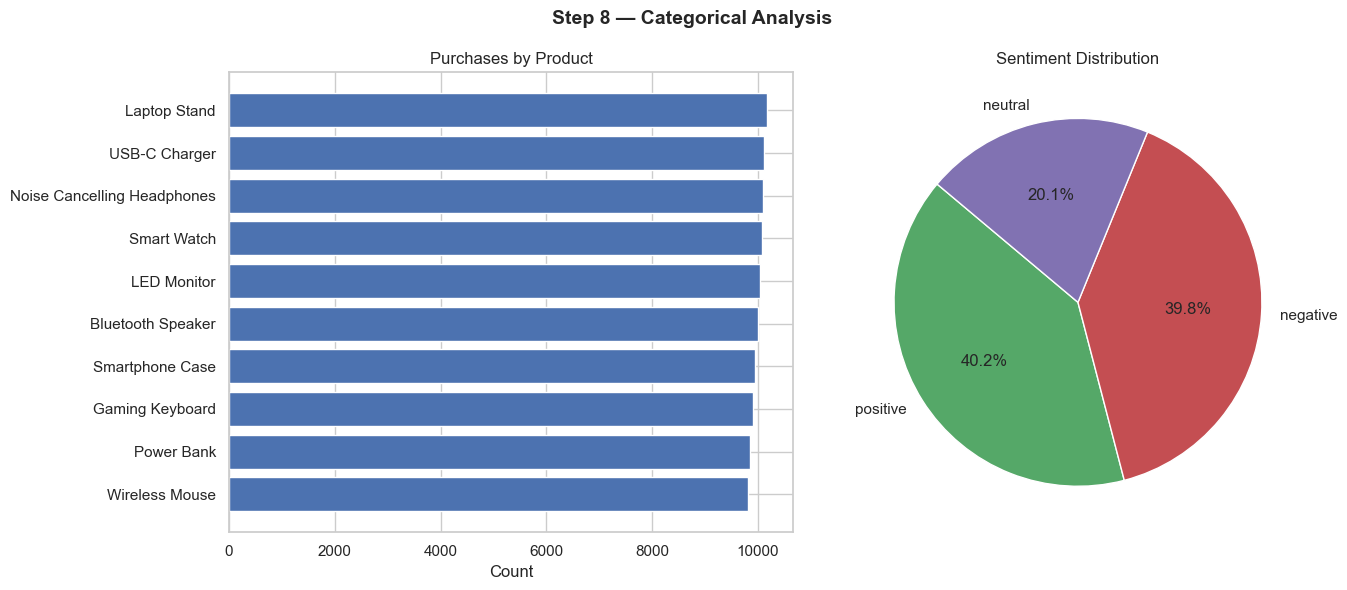

Saved: step8_categorical.png


In [27]:
 # sentiment plotting based on
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Step 8 — Categorical Analysis", fontsize=14, fontweight="bold")
 
prod_counts = df["product_name"].value_counts()
axes[0].barh(prod_counts.index[::-1], prod_counts.values[::-1], color="#4C72B0")
axes[0].set_title("Purchases by Product")
axes[0].set_xlabel("Count")
 
sent_counts = df["sentiment"].value_counts()
colors = ["#55A868", "#C44E52", "#8172B2"]
axes[1].pie(sent_counts.values, labels=sent_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140)
axes[1].set_title("Sentiment Distribution")
 
plt.tight_layout()
plt.savefig("step8_categorical.png", dpi=150)
plt.show()
print("Saved: step8_categorical.png")
 

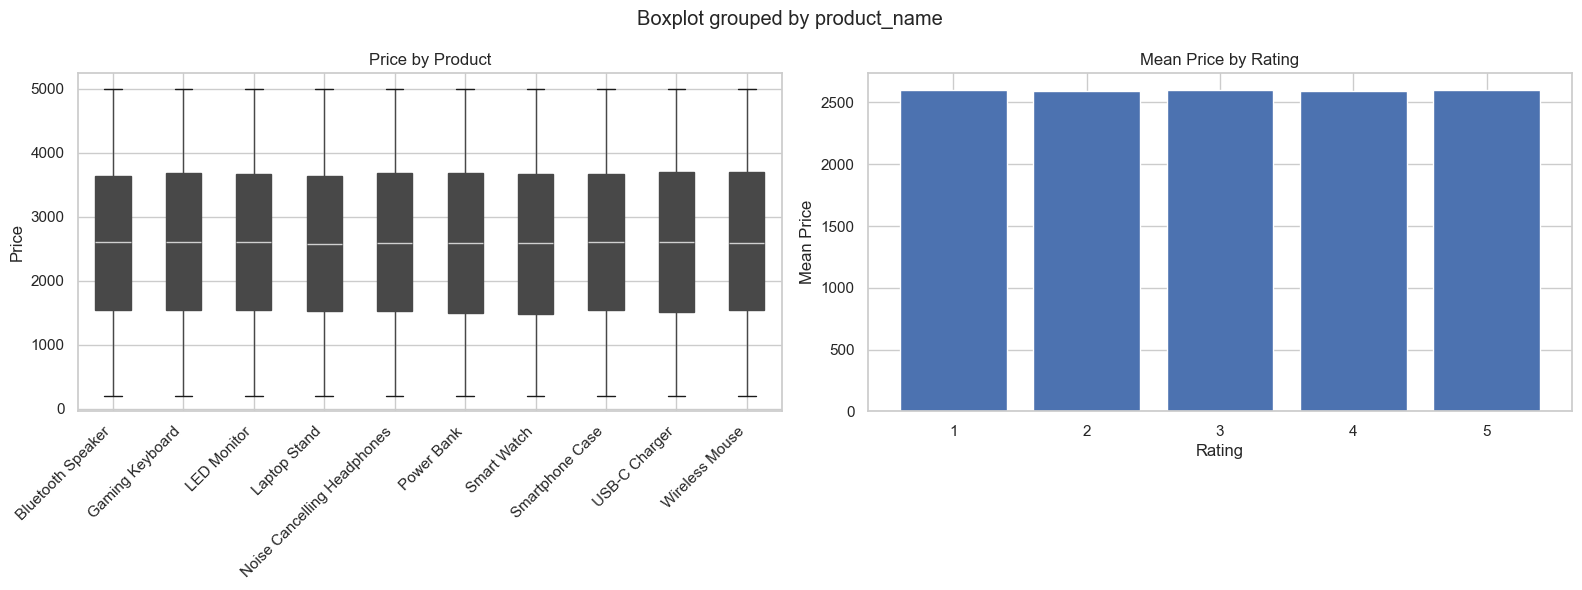

Saved: step9_price_analysis.png


In [28]:
#plotting based on price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Step 9 — Price Analysis", fontsize=14, fontweight="bold")
 
df.boxplot(column="price_filled", by="product_name", ax=axes[0],
           rot=45, patch_artist=True)
axes[0].set_title("Price by Product")
axes[0].set_xlabel("")
axes[0].set_ylabel("Price")
plt.sca(axes[0])
plt.xticks(ha="right")
 
mean_price_rating = df.groupby("rating")["price_filled"].mean()
axes[1].bar(mean_price_rating.index, mean_price_rating.values, color="#4C72B0", edgecolor="white")
axes[1].set_title("Mean Price by Rating")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Mean Price")
 
plt.tight_layout()
plt.savefig("step9_price_analysis.png", dpi=150)
plt.show()
print("Saved: step9_price_analysis.png")
 

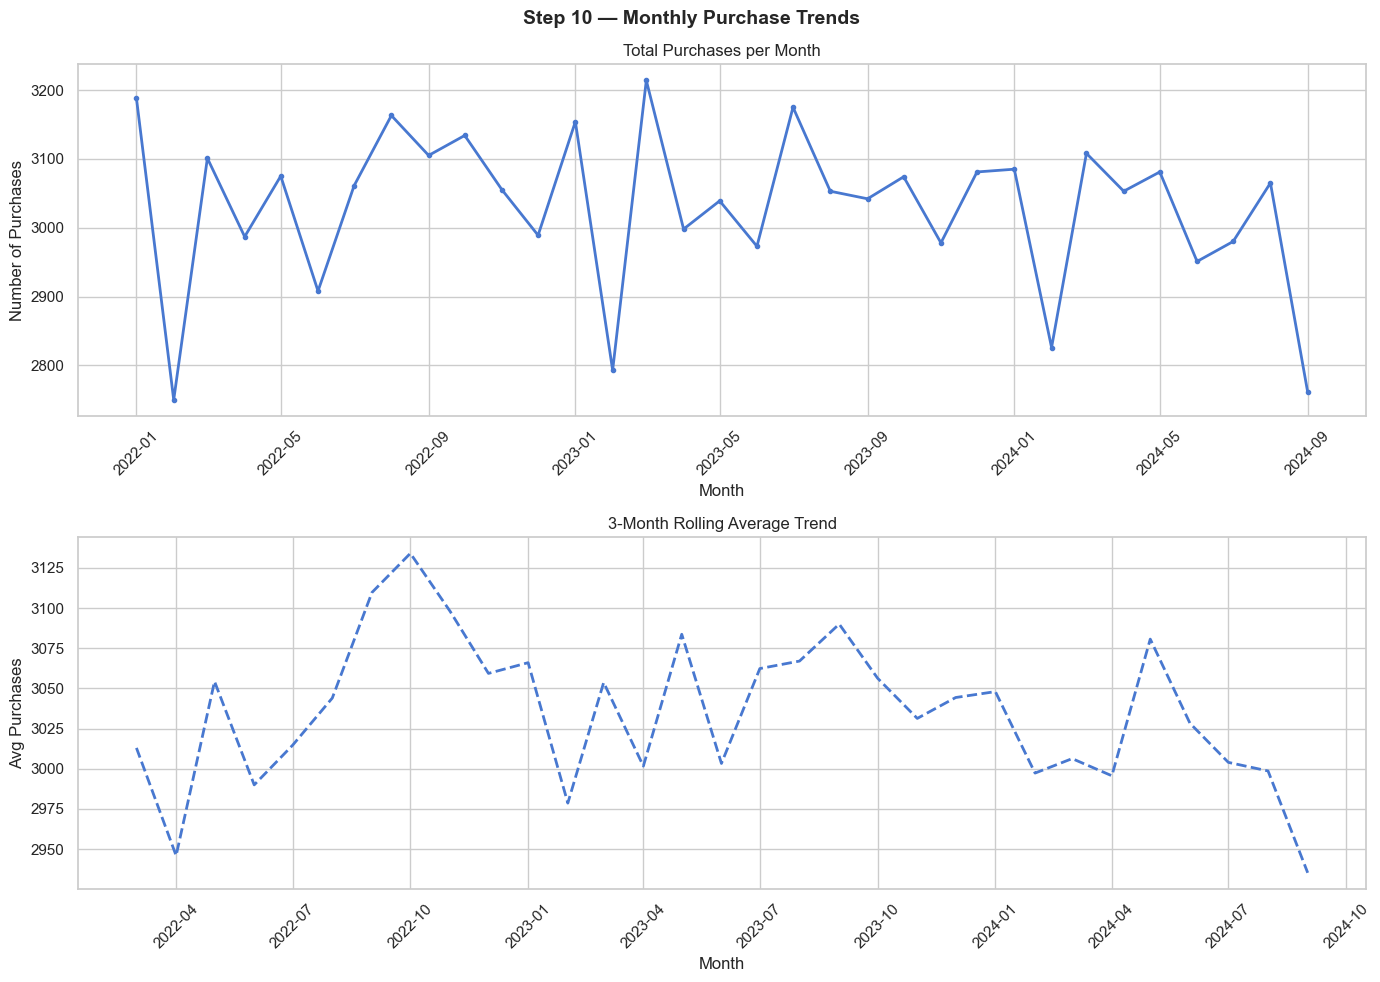

In [31]:
import matplotlib.pyplot as plt
df["date_of_purchase"] = pd.to_datetime(df["date_of_purchase"], errors="coerce")
# Create year-month column
df["year_month"] = df["date_of_purchase"].dt.to_period("M")

# Group data
monthly = df.groupby("year_month").size().reset_index(name="purchases")

# Convert to timestamp (for plotting)
monthly["year_month_dt"] = monthly["year_month"].dt.to_timestamp()

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Step 10 — Monthly Purchase Trends", fontsize=14, fontweight="bold")

# 📊 Plot 1: Overall Monthly Trend
axes[0].plot(
    monthly["year_month_dt"],
    monthly["purchases"],
    linewidth=2,
    marker="o",
    markersize=3
)
axes[0].set_title("Total Purchases per Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Purchases")
axes[0].tick_params(axis="x", rotation=45)

# 📊 Plot 2: Rolling Average (Trend Smooth)
monthly["rolling_avg"] = monthly["purchases"].rolling(window=3).mean()

axes[1].plot(
    monthly["year_month_dt"],
    monthly["rolling_avg"],
    linewidth=2,
    linestyle="--"
)
axes[1].set_title("3-Month Rolling Average Trend")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg Purchases")
axes[1].tick_params(axis="x", rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

In [33]:
sentiment_monthly = df.groupby(["year_month", "sentiment"]).size().reset_index(name="count")
sentiment_monthly["ym_dt"] = sentiment_monthly["year_month"].dt.to_timestamp()
palette = {"positive": "#55A868", "negative": "#C44E52", "neutral": "#8172B2"}
for sentiment, group in sentiment_monthly.groupby("sentiment"):
    axes[1].plot(group["ym_dt"], group["count"],
                 label=sentiment, color=palette[sentiment], linewidth=1.5)
axes[1].set_title("Monthly Purchases by Sentiment")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.savefig("step10_time_series.png", dpi=150)
plt.show()
print("Saved: step10_time_series.png")

<Figure size 640x480 with 0 Axes>

Saved: step10_time_series.png



STEP 11 — CORRELATION HEATMAP (saving: step11_correlation.png)
               price_filled  rating  review_length  sentiment_num
price_filled            1.0    0.00           -0.0           0.00
rating                  0.0    1.00           -0.0           0.95
review_length          -0.0   -0.00            1.0          -0.00
sentiment_num           0.0    0.95           -0.0           1.00


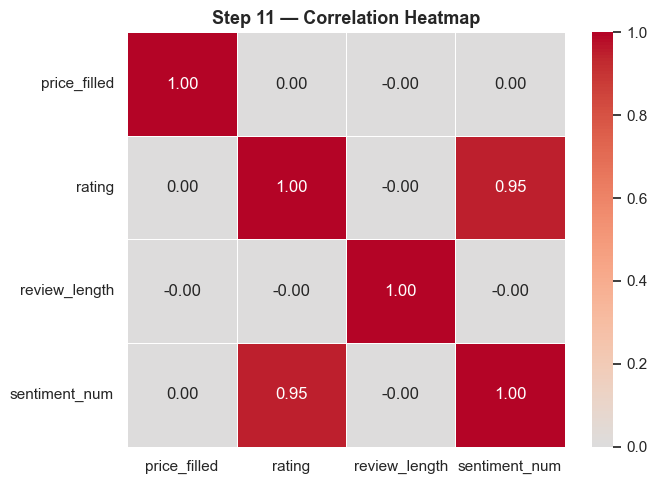

Saved: step11_correlation.png


In [23]:
#correlation 
print("\n" + "=" * 60)
print("STEP 11 — CORRELATION HEATMAP (saving: step11_correlation.png)")
print("=" * 60)
 
# Encode sentiment numerically for correlation
df["sentiment_num"] = df["sentiment"].map({"negative": -1, "neutral": 0, "positive": 1})
 
corr_cols = ["price_filled", "rating", "review_length", "sentiment_num"]
corr_matrix = df[corr_cols].corr().round(2)
print(corr_matrix)
 
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Step 11 — Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("step11_correlation.png", dpi=150)
plt.show()
print("Saved: step11_correlation.png")
 